<a href="https://colab.research.google.com/github/divya2212001/colabs/blob/main/Descriptive_Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lecture 15: Data Distribution & Outliers - PART I**


### **Core Objective**
Understand how data behaves (Shape + Outliers) and how to act on it

**Dataset: Walmart Sales Dataset:** https://drive.google.com/file/d/16Xij2C8nitiw1LsS7ZJQSYK78uSMQkYV/view?usp=sharing




Goal:
- Understand how numerical data is distributed
- Identify skewness
- Detect outliers using visuals and IQR

# Importing the Required libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset

In [6]:
from google.colab import files
uploaded = files.upload()

Saving Walmart.csv to Walmart.csv


In [8]:
df=pd.read_csv('Walmart.csv')
df.head()

,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,13-06-2013,17-06-2013,Darrin Van Huff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,6.87
1,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7.0,14.17
2,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Art,Newell 322,7.28,4.0,1.97
3,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Phones,Mitel 5320 IP Phone VoIP phone,907.15,4.0,90.72
4,CA-2011-115812,09-06-2011,14-06-2011,Brosina Hoffman,United States,Los Angeles,California,Binders,DXL Angle-View Binders with Locking Rings by S...,18.50,3.0,5.78


> **We'll use Walmart sales data because real business data usually has skewness and outliers**



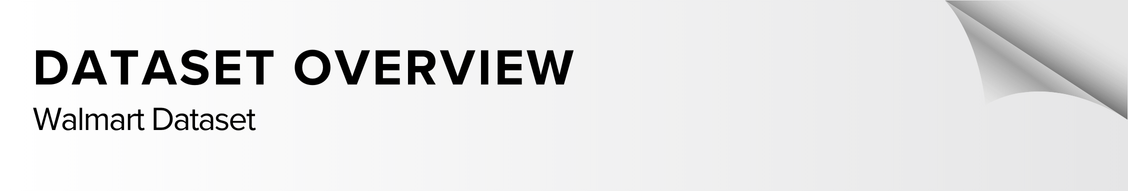

> **Total no of Rows and Columns in the Dataset**

In [9]:
print("Shape:", df.shape)

Shape: (3203, 12)


***df.shape*** the dimensions of a pandas DataFrame as a **tuple**.

> **Column Information and Data Types**

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       3203 non-null   object 
 1   Order Date     3203 non-null   object 
 2   Ship Date      3203 non-null   object 
 3   Customer Name  3203 non-null   object 
 4   Country        3203 non-null   object 
 5   City           3203 non-null   object 
 6   State          3203 non-null   object 
 7   Category       3203 non-null   object 
 8   Product Name   3203 non-null   object 
 9   Sales          3203 non-null   float64
 10  Quantity       3203 non-null   float64
 11  Profit         3203 non-null   float64
dtypes: float64(3), object(9)
memory usage: 300.4+ KB


***df.info*** is a concise technical summary of a pandas DataFrame.

> ***df.info()*** helps us quickly understand structure and data types

# Descriptive Statistics for Numerical Columns

In [11]:
df.describe()

,Sales,Quantity,Profit
count,3203.000000,3203.000000,3203.000000
mean,226.493266,3.828910,33.849138
std,524.876911,2.260947,174.109155
min,0.990000,1.000000,-3399.980000
25%,19.440000,2.000000,3.850000
50%,60.840000,3.000000,11.170000
75%,215.810000,5.000000,33.000000
max,13999.960000,14.000000,6719.980000


### Understanding the Data Distribution

In [12]:
df[['Sales', 'Quantity', 'Profit']].describe()

,Sales,Quantity,Profit
count,3203.000000,3203.000000,3203.000000
mean,226.493266,3.828910,33.849138
std,524.876911,2.260947,174.109155
min,0.990000,1.000000,-3399.980000
25%,19.440000,2.000000,3.850000
50%,60.840000,3.000000,11.170000
75%,215.810000,5.000000,33.000000
max,13999.960000,14.000000,6719.980000


**For Sales:**
* mean is much higher than median
* max is extremely large compared to Q3
* likely right-skewed
* likely contains outliers

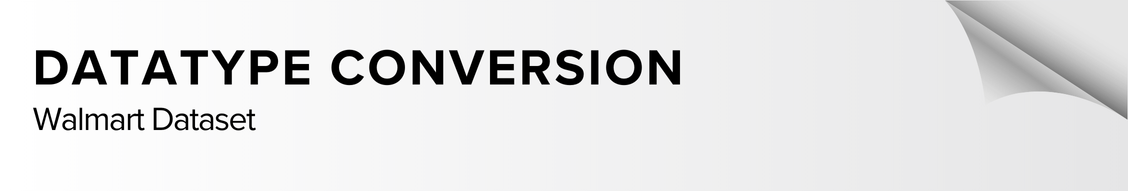

# Convert Order Date and Ship Date to datetime

> **Change the Data type of "`Order Date`", "`Ship Date`" "`Object`" to `Date`"**

In [13]:
df['Order Date'].head(10)

,Order Date
0,13-06-2013
1,09-06-2011
2,09-06-2011
3,09-06-2011
4,09-06-2011
5,09-06-2011
6,09-06-2011
7,09-06-2011
8,06-12-2013
9,13-05-2011


In [14]:
df['Order Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 3203 entries, 0 to 3202
Series name: Order Date
Non-Null Count  Dtype 
--------------  ----- 
3203 non-null   object
dtypes: object(1)
memory usage: 25.2+ KB


In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')

df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,2013-06-13,2013-06-17
1,2011-06-09,2011-06-14
2,2011-06-09,2011-06-14
3,2011-06-09,2011-06-14
4,2011-06-09,2011-06-14


In [16]:
df[['Order Date','Ship Date']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  3203 non-null   datetime64[ns]
 1   Ship Date   3203 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 50.2 KB


> ***Dates must be in datetime format for proper time analysis later***

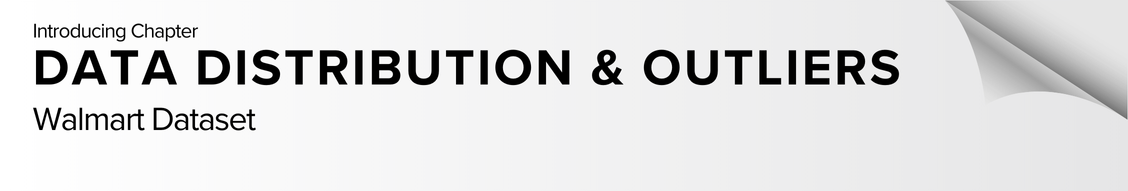

## What is data distribution?

It shows how values are spread.

## What are outliers?

They are unusually high or low values compared to the rest of the data.

Why it matters:
- helps us understand normal behavior
- helps us spot unusual transactions
- helps us avoid misleading conclusions

> ***Distribution tells us the shape. Outliers tell us what is unusual***

**Real-Life Examples - How Data Distribution impacts in Business Ideas**

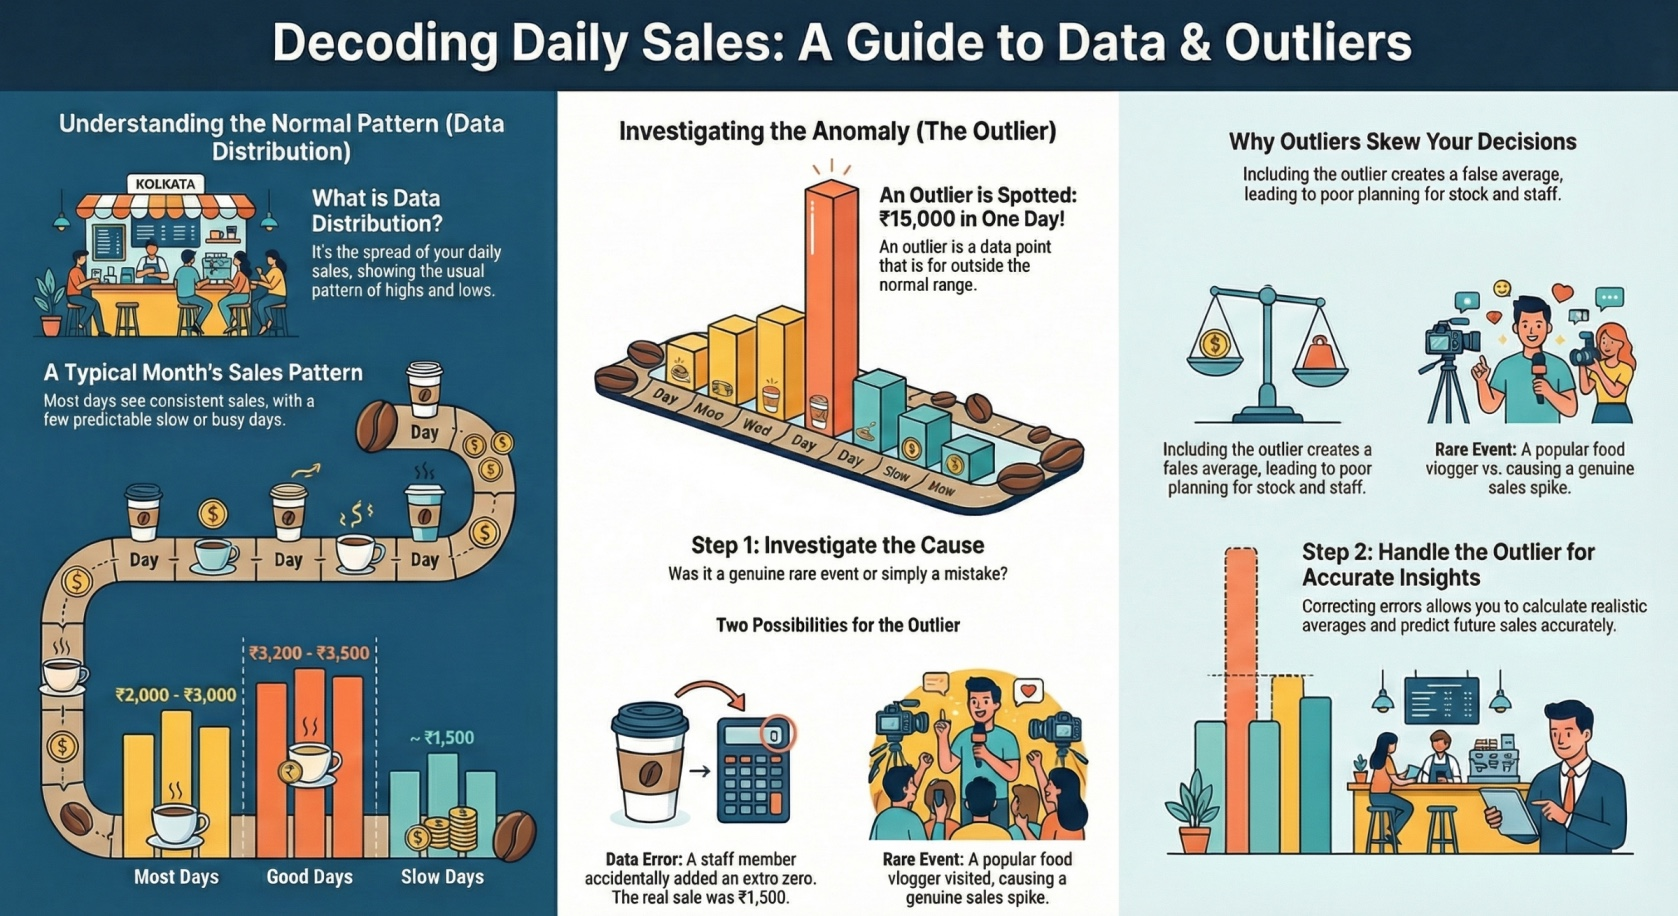

| **Distribution** | **Mean–Median–Mode Relationship** | **Explanation**                                                |
| ---------------- | --------------------------------- | -------------------------------------------------------------- |
| **Symmetric**    | Mean ≈ Median ≈ Mode              | Data is evenly balanced on both sides; no skewness present     |
| **Right-Skewed** | Mean > Median > Mode              | A few very large values pull the mean to the right             |
| **Left-Skewed**  | Mean < Median < Mode              | A few very small values pull the mean to the left              |

# **Understand Data Distribution from Sales Data**

In [17]:
sales_summary = df['Sales'].describe()
sales_summary

,Sales
count,3203.000000
mean,226.493266
std,524.876911
min,0.990000
25%,19.440000
50%,60.840000
75%,215.810000
max,13999.960000


> ***Let’s focus on one business metric and read its behavior properly***

## Quick interpretation of Sales

- Mean is much higher than median
- Most sales are relatively small
- A few very large sales pull the mean upward
- This suggests a right-skewed distribution

**Conclusion:**
- Sales is right-skewed.
- Most transactions are small.
- A few very large sales act as outliers.

## Before we look at the chart

Think about this:

- Are most sales similar in value?
- Or do a few transactions dominate the dataset?

Let’s validate this visually.

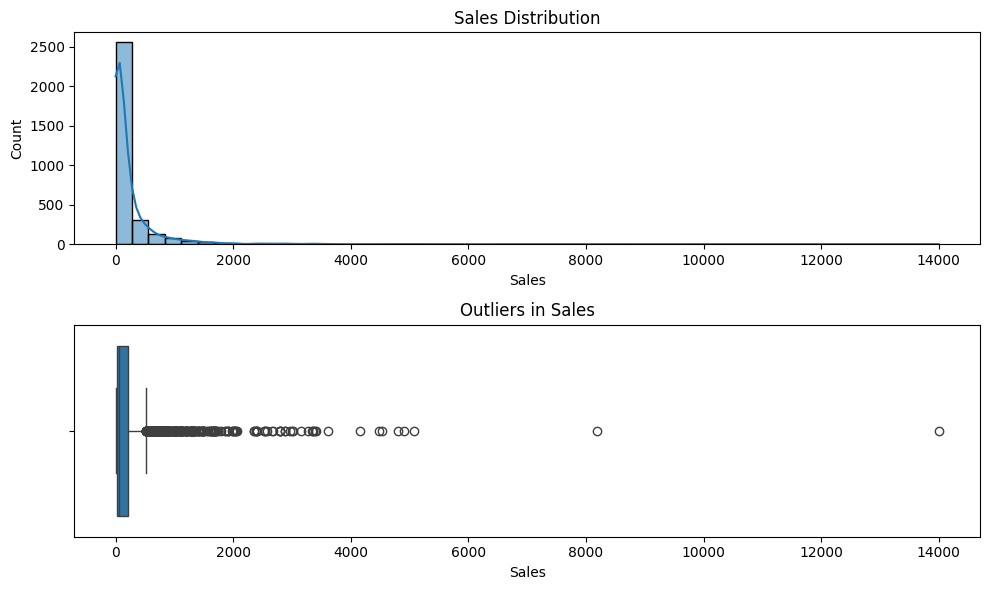

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# Histogram (Distribution)
sns.histplot(df['Sales'], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Sales Distribution")

# Boxplot (Outliers)
sns.boxplot(x=df['Sales'], ax=axes[1])
axes[1].set_title("Outliers in Sales")

plt.tight_layout()
plt.show()

## Observations from the Chart

From the top chart (distribution):

- Most values are concentrated on the lower side
- There is a long tail towards higher values
- This indicates a right-skewed distribution

From the bottom chart (boxplot):

- The main box represents the middle 50% of the data
- Several points lie far outside the box
- These are outliers — unusually high sales values

>***If I remove the top 1% of sales, what happens to the average?***


In [19]:
threshold = df['Sales'].quantile(0.99)

filtered_df = df[df['Sales'] <= threshold]

print("Original Mean:", df['Sales'].mean())
print("After Removing Top 1% Mean:", filtered_df['Sales'].mean())

Original Mean: 226.4932656884171
After Removing Top 1% Mean: 189.93954889589907


> ***Outliers don’t just exist — they change your conclusions.***
> ***That’s why analysts don’t trust averages blindly.***

## Key Takeaways

- Most real-world data is not evenly distributed
- A small number of large values can dominate the dataset

This means:
- Averages alone can mislead
- Decisions based only on mean can be wrong

As an analyst:
You must always check:
- Distribution
- Outliers
- Data shape

Before making conclusions

## Beyond This Lecture (Reference Concepts)

These concepts are important but will not be covered in depth today:

# A. **Skewness**  
Skewness tells us the direction in which the data is stretched.

A positive value means:
- Most values are small
- A few values are extremely large

This creates a long tail on the right side.

In our case, the high skewness confirms:
A few very large sales are significantly pulling the average upward.

Let’s confirm our visual observation numerically:

In [20]:
df['Sales'].skew()

np.float64(9.599750454757412)

If the value is **positive**, the distribution is **right-skewed**.

This matches what we observed visually.

# B. **Kurtosis**  
Kurtosis tells us how extreme the outliers are.

A very high value means:
- Most values are normal
- But a few values are extremely large compared to the rest

In our dataset, the very high kurtosis indicates:
There are rare but extremely large sales values.

In [21]:
df['Sales'].kurt()

np.float64(179.50081174842705)

> ***This also means the distribution has heavy tails due to extreme values***

What does this result mean?
- Higher kurtosis → more extreme outliers
- Lower kurtosis → fewer extreme values

# C. **IQR (Interquartile Range)**  

IQR measures the spread of the middle 50% of the data.

It helps us understand:
Where most of the data lies, ignoring extreme values.

We use IQR to define a normal range:
Values far outside this range are considered outliers.

In [22]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

IQR

np.float64(196.37)

>***This represents the typical spread of most sales values, excluding extremes.***

In [23]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Sales'] < lower_bound) |
              (df['Sales'] > upper_bound)]

outliers.shape

(368, 12)

> This means ***368*** rows fall outside the normal range..

> These extreme values are responsible for skewness and high kurtosis in the data.

`The 1.5 × IQR range is used as a practical boundary to identify unusually large or small values.`

Together:

- Skewness → tells direction
- Kurtosis → tells extremity
- IQR → helps detect outliers

Together, these help us understand:
- Why the data is skewed
- How extreme the outliers are
- And how they impact our analysis

## What should we do with outliers?

Not all outliers are bad.

- If they are errors → remove them
- If they are real → they may contain important insights

In this dataset:
These extreme sales are likely real, so instead of removing them,
we may choose to cap or transform them depending on the use case.

- **Outlier Treatment Techniques:**
  - Dropping incorrect values
  - Capping extreme values
  - Transforming data (e.g., log)

***In real-world analysis, handling outliers correctly can significantly change your results.***

## What’s Next?

Today, you learned how to read data.

In the next lecture, you will learn how to:
- Build these visuals from scratch
- Control how they look
- Turn analysis into storytelling

Right now you can interpret charts.

Next, you will create them.

## Final Thought

Data does not always behave nicely.

If you do not understand its shape,
you can easily draw the wrong conclusions.

Always look beyond the average.

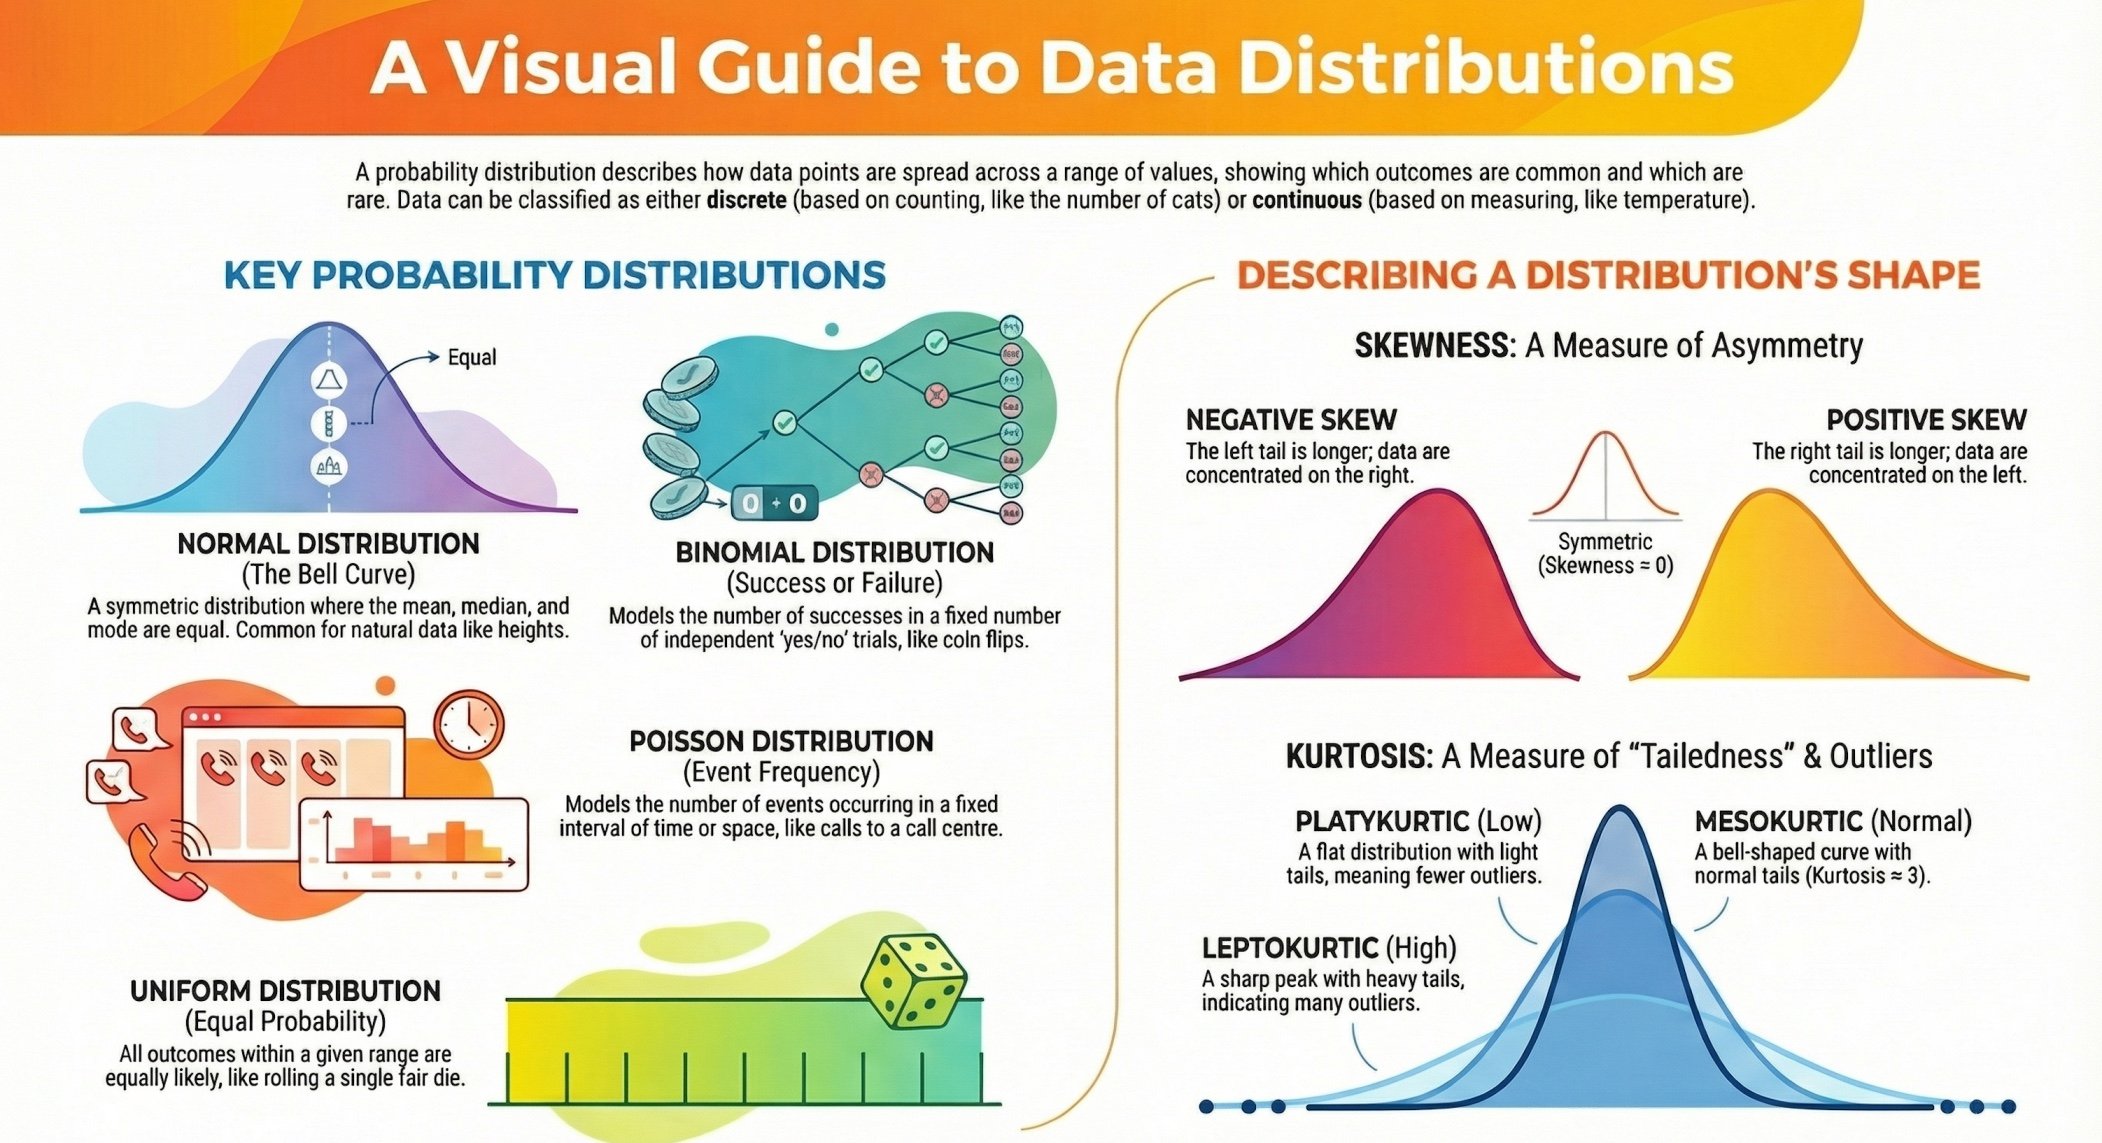

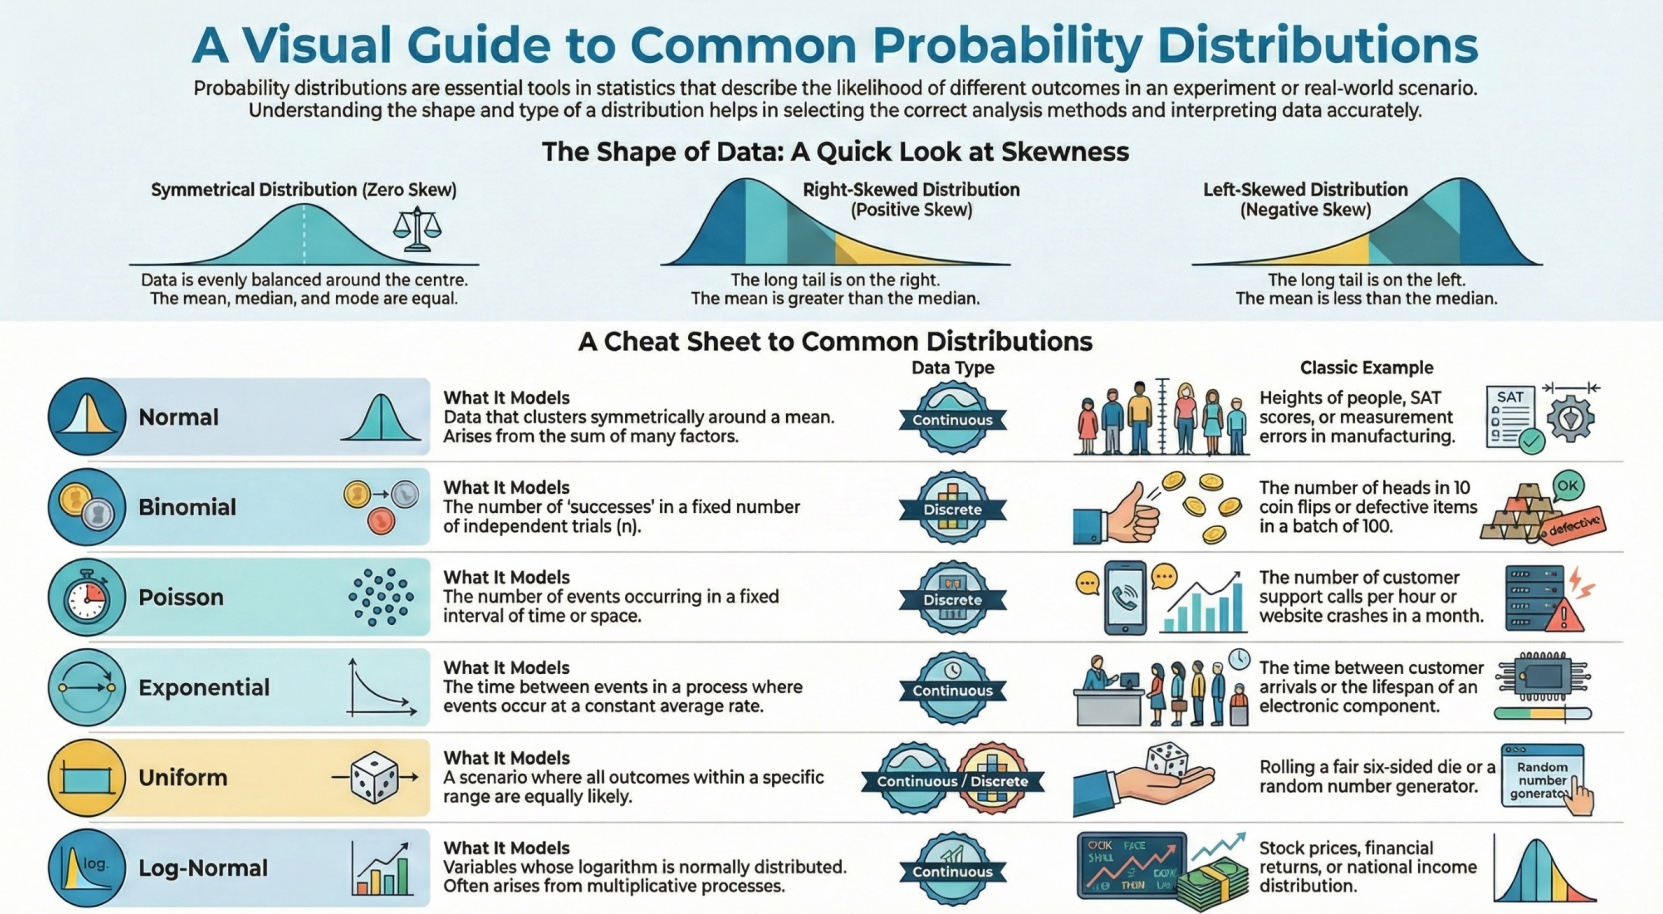